<a href="https://colab.research.google.com/github/oviccenzo/optativa-1-ciencia-de-dados/blob/main/08_CienciaDados_CC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%%capture
#!pip install pycaret

In [ ]:
# %%capture
# !pip install ydata-profiling

In [ ]:
# %%capture
# !pip install pycaret[analysis]
# # ydata-profiling

In [ ]:
# Desinstala os pacotes que podem estar causando o conflito
%%capture
!pip uninstall pycaret -y
!pip uninstall ydata-profiling -y
!pip uninstall pandas -y
!pip uninstall numpy -y # Garante que o numpy também seja removido

# Reinstala pycaret com as dependências de análise (que incluem ydata-profiling e as versões compatíveis de pandas e numpy)
!pip install pycaret[analysis]

# Você não precisa reinstalar ydata-profiling separadamente, pois pycaret[analysis] já o inclui.

# Agora você pode importar e executar o restante do seu código
from pycaret.datasets import get_data
from pycaret.classification import *
from ydata_profiling import ProfileReport
# As importações agora devem funcionar sem o erro de incompatibilidade do numpy

In [ ]:
# from pycaret.datasets import get_data
# from pycaret.classification import *
# from ydata_profiling import ProfileReport
# from pycaret.datasets import get_data

In [ ]:
data = get_data('diabetes', profile=True)


In [ ]:
s = setup(data, target = 'Class variable', session_id = 123)

,Description,Value
0,Session id,123
1,Target,Class variable
2,Target type,Binary
3,Original data shape,"(768, 9)"
4,Transformed data shape,"(768, 9)"
5,Transformed train set shape,"(537, 9)"
6,Transformed test set shape,"(231, 9)"
7,Numeric features,8
8,Preprocess,True
9,Imputation type,simple


In [ ]:
#Comparar modelos
best = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.7689,0.8047,0.5602,0.7208,0.6279,0.4641,0.4736,1.0430
ridge,Ridge Classifier,0.7670,0.8060,0.5497,0.7235,0.6221,0.4581,0.4690,0.0310
lda,Linear Discriminant Analysis,0.7670,0.8055,0.5550,0.7202,0.6243,0.4594,0.4695,0.0310
rf,Random Forest Classifier,0.7485,0.7911,0.5284,0.6811,0.5924,0.4150,0.4238,0.2300
nb,Naive Bayes,0.7427,0.7955,0.5702,0.6543,0.6043,0.4156,0.4215,0.0320
gbc,Gradient Boosting Classifier,0.7373,0.7909,0.5550,0.6445,0.5931,0.4013,0.4059,0.1840
ada,Ada Boost Classifier,0.7372,0.7799,0.5275,0.6585,0.5796,0.3926,0.4017,0.2360
et,Extra Trees Classifier,0.7299,0.7788,0.4965,0.6516,0.5596,0.3706,0.3802,0.1830
qda,Quadratic Discriminant Analysis,0.7282,0.7894,0.5281,0.6558,0.5736,0.3785,0.3910,0.0330
lightgbm,Light Gradient Boosting Machine,0.7133,0.7645,0.5398,0.6036,0.5650,0.3534,0.3580,0.2740


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [ ]:
print(best)

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=123, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)


In [ ]:
knn = create_model('lr')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8704,0.9008,0.7368,0.8750,0.8000,0.7051,0.7108
1,0.8148,0.7880,0.6316,0.8000,0.7059,0.5735,0.5820
2,0.8704,0.9308,0.6842,0.9286,0.7879,0.6976,0.7145
3,0.6852,0.7744,0.4737,0.5625,0.5143,0.2839,0.2862
4,0.8704,0.9128,0.6842,0.9286,0.7879,0.6976,0.7145
5,0.6481,0.6722,0.3684,0.5000,0.4242,0.1792,0.1835
6,0.7407,0.8030,0.5789,0.6471,0.6111,0.4176,0.4190
7,0.7736,0.8730,0.4444,0.8000,0.5714,0.4342,0.4688
8,0.6604,0.6810,0.4444,0.5000,0.4706,0.2219,0.2227


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
rigde = create_model('ridge')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8333,0.8962,0.6316,0.8571,0.7273,0.6112,0.6260
1,0.8148,0.7895,0.6316,0.8000,0.7059,0.5735,0.5820
2,0.8704,0.9293,0.6842,0.9286,0.7879,0.6976,0.7145
3,0.7222,0.7805,0.4737,0.6429,0.5455,0.3520,0.3605
4,0.8704,0.9173,0.6842,0.9286,0.7879,0.6976,0.7145
5,0.6481,0.6602,0.3684,0.5000,0.4242,0.1792,0.1835
6,0.7222,0.8045,0.5789,0.6111,0.5946,0.3836,0.3839
7,0.7736,0.8794,0.4444,0.8000,0.5714,0.4342,0.4688
8,0.6604,0.6810,0.4444,0.5000,0.4706,0.2219,0.2227


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
nb = create_model('nb')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7963,0.8632,0.7368,0.7000,0.7179,0.5587,0.5591
1,0.7222,0.7639,0.6316,0.6000,0.6154,0.3982,0.3985
2,0.8148,0.9474,0.6316,0.8000,0.7059,0.5735,0.5820
3,0.7407,0.7624,0.5789,0.6471,0.6111,0.4176,0.4190
4,0.8333,0.8722,0.5789,0.9167,0.7097,0.6010,0.6322
5,0.6667,0.6827,0.4737,0.5294,0.5000,0.2512,0.2520
6,0.7778,0.7699,0.7368,0.6667,0.7000,0.5242,0.5259
7,0.6981,0.8222,0.3889,0.5833,0.4667,0.2677,0.2784
8,0.6604,0.7000,0.4444,0.5000,0.4706,0.2219,0.2227


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
#turnagem dos modelos
turned_best = tune_model(best)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8704,0.8992,0.7368,0.8750,0.8000,0.7051,0.7108
1,0.8148,0.7850,0.6316,0.8000,0.7059,0.5735,0.5820
2,0.8704,0.9353,0.6842,0.9286,0.7879,0.6976,0.7145
3,0.7222,0.7744,0.4737,0.6429,0.5455,0.3520,0.3605
4,0.8704,0.9113,0.6842,0.9286,0.7879,0.6976,0.7145
5,0.6481,0.6662,0.3684,0.5000,0.4242,0.1792,0.1835
6,0.7407,0.8030,0.5789,0.6471,0.6111,0.4176,0.4190
7,0.7736,0.8746,0.4444,0.8000,0.5714,0.4342,0.4688
8,0.6604,0.6778,0.4444,0.5000,0.4706,0.2219,0.2227


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


In [ ]:
rigde_turned = tune_model(rigde)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8519,0.8977,0.6842,0.8667,0.7647,0.6588,0.6686
1,0.8148,0.7910,0.6316,0.8000,0.7059,0.5735,0.5820
2,0.8704,0.9278,0.6842,0.9286,0.7879,0.6976,0.7145
3,0.7222,0.7805,0.4737,0.6429,0.5455,0.3520,0.3605
4,0.8704,0.9173,0.6842,0.9286,0.7879,0.6976,0.7145
5,0.6481,0.6647,0.3684,0.5000,0.4242,0.1792,0.1835
6,0.7222,0.8030,0.5789,0.6111,0.5946,0.3836,0.3839
7,0.7736,0.8746,0.4444,0.8000,0.5714,0.4342,0.4688
8,0.6604,0.6794,0.4444,0.5000,0.4706,0.2219,0.2227


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


In [ ]:
evaluate_model(turned_best)
# evaluate_model(lr_turned)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [ ]:
import pandas as pd
from pycaret.classification import *


evaluate_model(rigde_turned)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

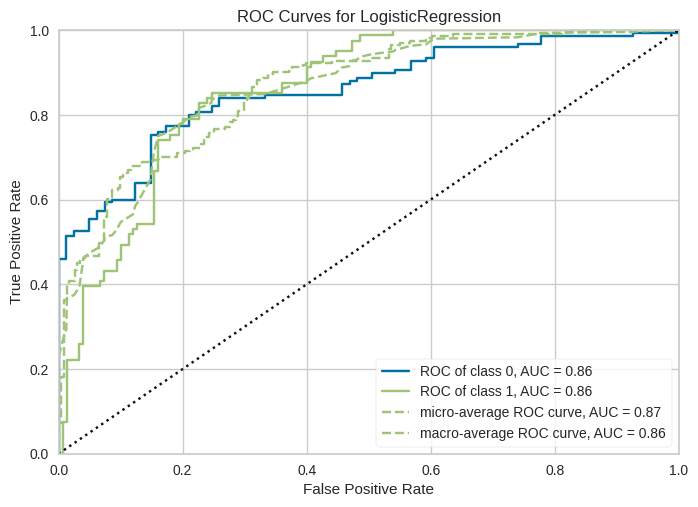

In [ ]:
plot_model(turned_best)

In [ ]:
predictions = predict_model(turned_best, data = data, raw_score = True)
predictions.head(10)


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.7773,0.8361,0.5709,0.7321,0.6415,0.4836,0.4915


,Number of times pregnant,Plasma glucose concentration a 2 hours in an oral glucose tolerance test,Diastolic blood pressure (mm Hg),Triceps skin fold thickness (mm),2-Hour serum insulin (mu U/ml),Body mass index (weight in kg/(height in m)^2),Diabetes pedigree function,Age (years),Class variable,prediction_label,prediction_score_0,prediction_score_1
0,6,148,72,35,0,33.599998,0.627,50,1,1,0.3044,0.6956
1,1,85,66,29,0,26.600000,0.351,31,0,0,0.9426,0.0574
2,8,183,64,0,0,23.299999,0.672,32,1,1,0.1993,0.8007
3,1,89,66,23,94,28.100000,0.167,21,0,0,0.9465,0.0535
4,0,137,40,35,168,43.099998,2.288,33,1,1,0.1457,0.8543
5,5,116,74,0,0,25.600000,0.201,30,0,0,0.8376,0.1624
6,3,78,50,32,88,31.000000,0.248,26,1,0,0.9249,0.0751
7,10,115,0,0,0,35.299999,0.134,29,0,1,0.3809,0.6191
8,2,197,70,45,543,30.500000,0.158,53,1,1,0.3124,0.6876
9,8,125,96,0,0,0.000000,0.232,54,1,0,0.9624,0.0376


In [ ]:
import pandas as pd

df = pd.DataFrame(columns=data.columns.difference(['Class variable'], sort=False))
df.head(10)

,Number of times pregnant,Plasma glucose concentration a 2 hours in an oral glucose tolerance test,Diastolic blood pressure (mm Hg),Triceps skin fold thickness (mm),2-Hour serum insulin (mu U/ml),Body mass index (weight in kg/(height in m)^2),Diabetes pedigree function,Age (years)


In [ ]:
df.loc[0] = [0,148,72,35,0,33.59,1.627,50]

In [ ]:
predictions = predict_model(turned_best, data = df, raw_score = True)
predictions

,Number of times pregnant,Plasma glucose concentration a 2 hours in an oral glucose tolerance test,Diastolic blood pressure (mm Hg),Triceps skin fold thickness (mm),2-Hour serum insulin (mu U/ml),Body mass index (weight in kg/(height in m)^2),Diabetes pedigree function,Age (years),prediction_label,prediction_score_0,prediction_score_1
0,0.0,148.0,72.0,35.0,0.0,33.59,1.627,50.0,1,0.2925,0.7075


In [ ]:
save_model(turned_best, 'best_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['Number of times pregnant',
                                              'Plasma glucose concentration a 2 '
                                              'hours in an oral glucose '
                                              'tolerance test',
                                              'Diastolic blood pressure (mm Hg)',
                                              'Triceps skin fold thickness (mm)',
                                              '2-Hour serum insulin (mu U/ml)',
                                              'Body mass index (weight in '
                                              'kg/(height in m)^2)',
                                              'Diabetes pedigre...
                  TransformerWrapper(exclude=None, include=None,
                                     transformer=CleanC

In [ ]:
load_experiment= load_model('best_model')
print(load_experiment)

Transformation Pipeline and Model Successfully Loaded
Pipeline(memory=FastMemory(location=/tmp/joblib),
         steps=[('numerical_imputer',
                 TransformerWrapper(exclude=None,
                                    include=['Number of times pregnant',
                                             'Plasma glucose concentration a 2 '
                                             'hours in an oral glucose '
                                             'tolerance test',
                                             'Diastolic blood pressure (mm Hg)',
                                             'Triceps skin fold thickness (mm)',
                                             '2-Hour serum insulin (mu U/ml)',
                                             'Body mass index (weight in '
                                             'kg/(height in m)^2)',
                                             'Diab...
                 TransformerWrapper(exclude=None, include=None,
                